# Módulo 1 — Riesgo de Crédito
## Notebook 1: Exploración de Datos (EDA)

---

**Contexto de negocio:**  
Una entidad financiera necesita mejorar su modelo de concesión de créditos.  
El objetivo es identificar qué variables predicen mejor el riesgo de impago,  
para apoyar decisiones más informadas en el proceso de scoring crediticio.

**Dataset:** German Credit Dataset (UCI Machine Learning Repository)  
**Observaciones:** 1.000 clientes  
**Variable objetivo:** `riesgo` — 1 = buen pagador · 2 = mal pagador

---

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


El dataset `german.data` no tiene cabecera, así que la asignamos manualmente según la documentación oficial del UCI.

In [2]:
columnas = [
    'estado_cuenta', 'duracion_meses', 'historial_credito', 'proposito',
    'importe', 'ahorro', 'empleo_actual', 'tasa_cuota',
    'estado_civil_sexo', 'otros_deudores', 'residencia_actual',
    'propiedad', 'edad', 'otros_planes', 'vivienda',
    'creditos_existentes', 'trabajo', 'personas_dependientes',
    'telefono', 'trabajador_extranjero', 'riesgo'
]

df = pd.read_csv('../../datos/raw/german.data', sep=' ', header=None, names=columnas)

print(f'✅ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

✅ Dataset cargado: 1000 filas × 21 columnas


,estado_cuenta,duracion_meses,historial_credito,proposito,importe,ahorro,empleo_actual,tasa_cuota,estado_civil_sexo,otros_deudores,...,propiedad,edad,otros_planes,vivienda,creditos_existentes,trabajo,personas_dependientes,telefono,trabajador_extranjero,riesgo
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


### 1.1 Traducción de códigos categóricos

El dataset original usa códigos internos (A71, A34...) definidos en la documentación UCI.  
Los traducimos a etiquetas legibles para que los análisis sean interpretables.

In [3]:
mapeo_estado_cuenta = {
    'A11': 'Saldo < 0 DM',
    'A12': '0 ≤ Saldo < 200 DM',
    'A13': 'Saldo ≥ 200 DM',
    'A14': 'Sin cuenta corriente'
}
mapeo_historial = {
    'A30': 'Sin créditos / todos pagados',
    'A31': 'Todos pagados en este banco',
    'A32': 'Créditos actuales al día',
    'A33': 'Retrasos en el pasado',
    'A34': 'Cuenta crítica / créditos en otros bancos'
}
mapeo_proposito = {
    'A40': 'Coche (nuevo)',
    'A41': 'Coche (usado)',
    'A42': 'Muebles / equipamiento',
    'A43': 'Radio / televisión',
    'A44': 'Electrodomésticos',
    'A45': 'Reparaciones',
    'A46': 'Educación',
    'A48': 'Reciclaje profesional',
    'A49': 'Negocio',
    'A410': 'Otros'
}
mapeo_ahorro = {
    'A61': 'Ahorro < 100 DM',
    'A62': '100 ≤ Ahorro < 500 DM',
    'A63': '500 ≤ Ahorro < 1000 DM',
    'A64': 'Ahorro ≥ 1000 DM',
    'A65': 'Sin cuenta de ahorro'
}
mapeo_empleo = {
    'A71': 'Desempleado',
    'A72': 'Empleo < 1 año',
    'A73': '1 ≤ Empleo < 4 años',
    'A74': '4 ≤ Empleo < 7 años',
    'A75': 'Empleo ≥ 7 años'
}
mapeo_estado_civil = {
    'A91': 'Hombre divorciado/separado',
    'A92': 'Mujer divorciada/casada',
    'A93': 'Hombre soltero',
    'A94': 'Hombre casado/viudo',
    'A95': 'Mujer soltera'
}
mapeo_propiedad = {
    'A121': 'Inmueble',
    'A122': 'Seguro de vida / contrato ahorro',
    'A123': 'Coche u otro bien',
    'A124': 'Sin propiedad conocida'
}
mapeo_vivienda = {
    'A151': 'Alquiler',
    'A152': 'Propiedad propia',
    'A153': 'Vivienda gratuita'
}
mapeo_trabajo = {
    'A171': 'Desempleado / no cualificado (no residente)',
    'A172': 'No cualificado (residente)',
    'A173': 'Empleado cualificado',
    'A174': 'Directivo / autónomo / altamente cualificado'
}

df['estado_cuenta']     = df['estado_cuenta'].map(mapeo_estado_cuenta)
df['historial_credito'] = df['historial_credito'].map(mapeo_historial)
df['proposito']         = df['proposito'].map(mapeo_proposito)
df['ahorro']            = df['ahorro'].map(mapeo_ahorro)
df['empleo_actual']     = df['empleo_actual'].map(mapeo_empleo)
df['estado_civil_sexo'] = df['estado_civil_sexo'].map(mapeo_estado_civil)
df['propiedad']         = df['propiedad'].map(mapeo_propiedad)
df['vivienda']          = df['vivienda'].map(mapeo_vivienda)
df['trabajo']           = df['trabajo'].map(mapeo_trabajo)
df['riesgo_label']      = df['riesgo'].map({1: 'Buen pagador', 2: 'Mal pagador'})

print('✅ Códigos traducidos correctamente')
df[['historial_credito', 'empleo_actual', 'proposito', 'riesgo_label']].head(8)

✅ Códigos traducidos correctamente


,historial_credito,empleo_actual,proposito,riesgo_label
0,Cuenta crítica / créditos en otros bancos,Empleo ≥ 7 años,Radio / televisión,Buen pagador
1,Créditos actuales al día,1 ≤ Empleo < 4 años,Radio / televisión,Mal pagador
2,Cuenta crítica / créditos en otros bancos,4 ≤ Empleo < 7 años,Educación,Buen pagador
3,Créditos actuales al día,4 ≤ Empleo < 7 años,Muebles / equipamiento,Buen pagador
4,Retrasos en el pasado,1 ≤ Empleo < 4 años,Coche (nuevo),Mal pagador
5,Créditos actuales al día,1 ≤ Empleo < 4 años,Educación,Buen pagador
6,Créditos actuales al día,Empleo ≥ 7 años,Muebles / equipamiento,Buen pagador
7,Créditos actuales al día,1 ≤ Empleo < 4 años,Coche (usado),Buen pagador


## 2. Inspección inicial

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   estado_cuenta          1000 non-null   object
 1   duracion_meses         1000 non-null   int64 
 2   historial_credito      1000 non-null   object
 3   proposito              1000 non-null   object
 4   importe                1000 non-null   int64 
 5   ahorro                 1000 non-null   object
 6   empleo_actual          1000 non-null   object
 7   tasa_cuota             1000 non-null   int64 
 8   estado_civil_sexo      1000 non-null   object
 9   otros_deudores         1000 non-null   object
 10  residencia_actual      1000 non-null   int64 
 11  propiedad              1000 non-null   object
 12  edad                   1000 non-null   int64 
 13  otros_planes           1000 non-null   object
 14  vivienda               1000 non-null   object
 15  creditos_existentes   

In [5]:
df.describe()

,duracion_meses,importe,tasa_cuota,residencia_actual,edad,creditos_existentes,personas_dependientes,riesgo
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [6]:
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ No hay valores nulos en el dataset')

Valores nulos por columna:
✅ No hay valores nulos en el dataset


## 3. Análisis de la variable objetivo

Antes de analizar nada más, necesitamos entender cómo está distribuida nuestra variable objetivo (`riesgo`).  
En scoring crediticio, un **desbalance** entre buenos y malos pagadores es habitual — y tiene implicaciones directas en cómo construiremos el modelo.

           Clase  Cantidad Porcentaje
Buen pagador (1)       700      70.0%
 Mal pagador (2)       300      30.0%


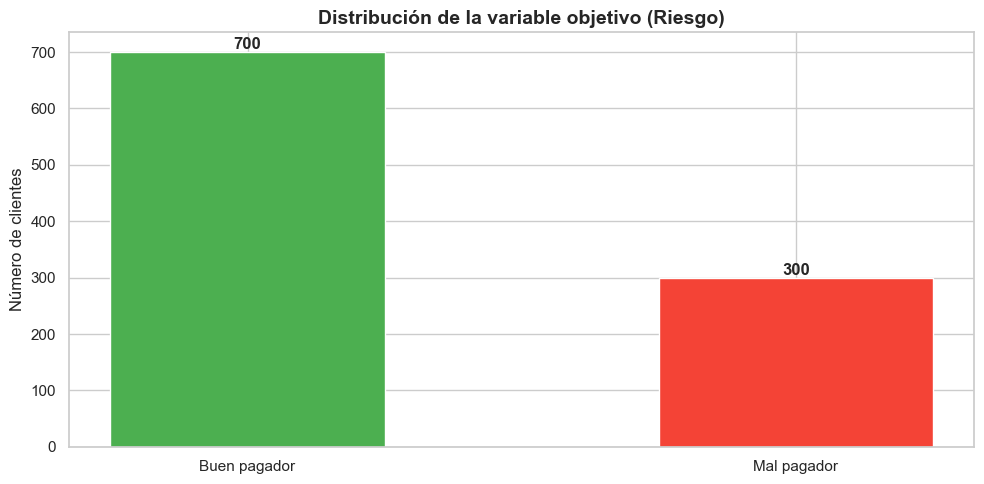

In [7]:
conteo = df['riesgo'].value_counts()
porcentaje = df['riesgo'].value_counts(normalize=True) * 100

resumen_objetivo = pd.DataFrame({
    'Clase': ['Buen pagador (1)', 'Mal pagador (2)'],
    'Cantidad': [conteo[1], conteo[2]],
    'Porcentaje': [f"{porcentaje[1]:.1f}%", f"{porcentaje[2]:.1f}%"]
})
print(resumen_objetivo.to_string(index=False))

fig, ax = plt.subplots()
colores = ['#4CAF50', '#F44336']
ax.bar(['Buen pagador', 'Mal pagador'], [conteo[1], conteo[2]], color=colores, width=0.5)
ax.set_title('Distribución de la variable objetivo (Riesgo)', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de clientes')
for i, v in enumerate([conteo[1], conteo[2]]):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Conclusión de negocio:** El dataset presenta un desbalance 70/30 entre buenos y malos pagadores. Este ratio es realista para carteras bancarias reales. En el notebook de preprocesamiento aplicaremos técnicas para gestionar este desbalance antes de modelar.

## 4. Análisis de variables numéricas clave

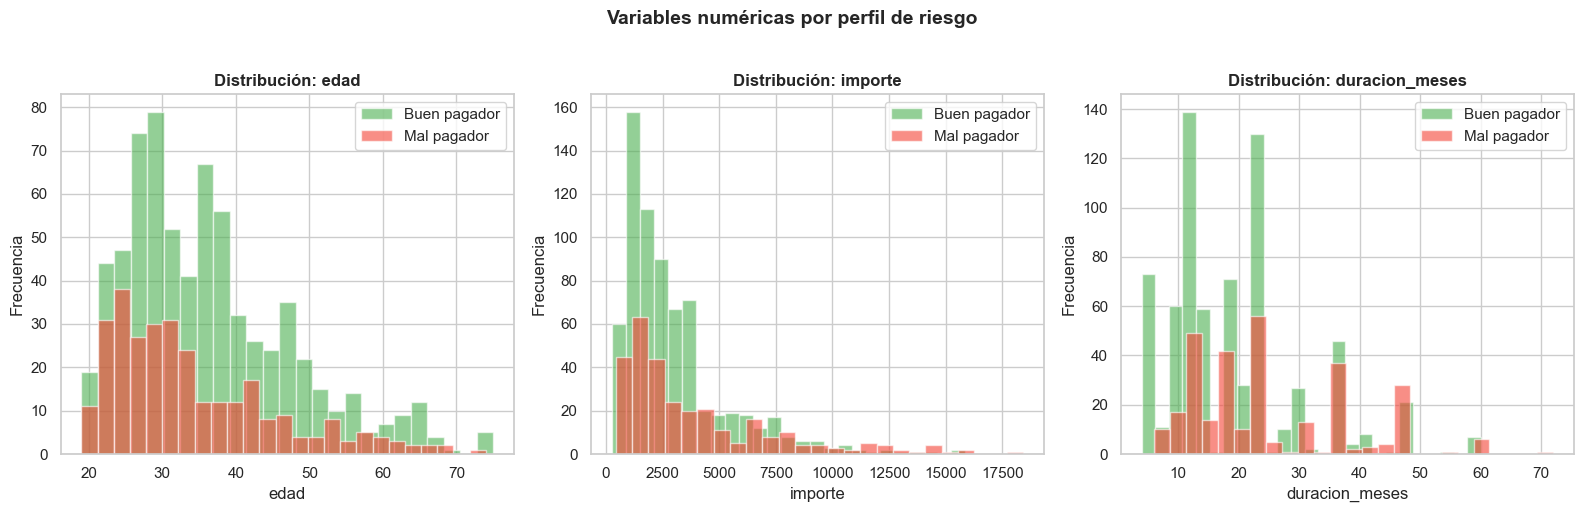

In [8]:
vars_numericas = ['edad', 'importe', 'duracion_meses']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, var in enumerate(vars_numericas):
    for clase, color, label in zip([1, 2], ['#4CAF50', '#F44336'], ['Buen pagador', 'Mal pagador']):
        axes[i].hist(df[df['riesgo'] == clase][var], bins=25, alpha=0.6, color=color, label=label)
    axes[i].set_title(f'Distribución: {var}', fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.suptitle('Variables numéricas por perfil de riesgo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
comparativa = df.groupby('riesgo_label')[vars_numericas].agg(['mean', 'median']).round(1)
print('Estadísticas comparativas por perfil de riesgo:')
print(comparativa)

Estadísticas comparativas por perfil de riesgo:
              edad        importe         duracion_meses       
              mean median    mean  median           mean median
riesgo_label                                                   
Buen pagador  36.2   34.0  2985.5  2244.0           19.2   18.0
Mal pagador   34.0   31.0  3938.1  2574.5           24.9   24.0


## 5. Análisis de variables categóricas clave

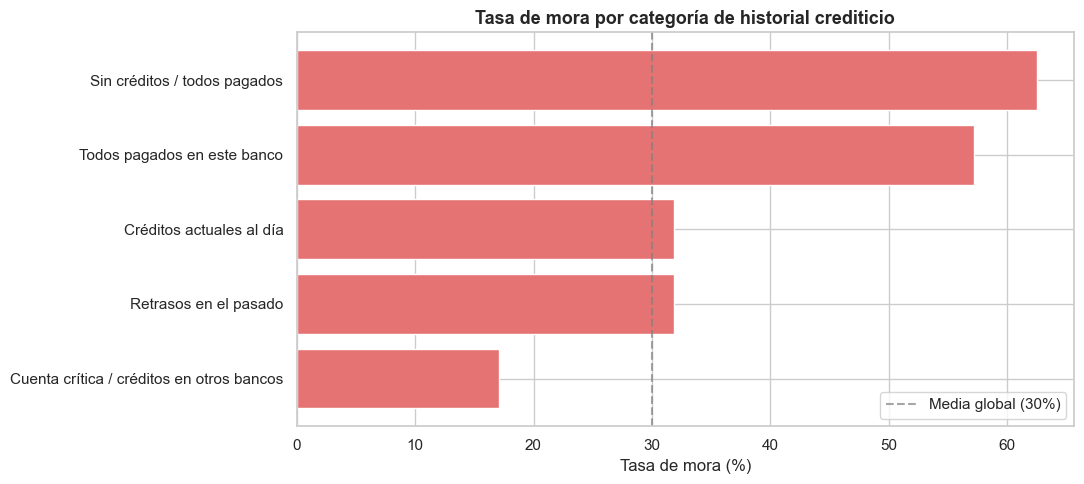

In [10]:
# Tasa de mora por historial crediticio
tasa_mora = df.groupby('historial_credito')['riesgo'].apply(
    lambda x: (x == 2).sum() / len(x) * 100
).reset_index()
tasa_mora.columns = ['historial_credito', 'tasa_mora_%']
tasa_mora = tasa_mora.sort_values('tasa_mora_%', ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(tasa_mora['historial_credito'], tasa_mora['tasa_mora_%'], color='#E57373')
ax.set_title('Tasa de mora por categoría de historial crediticio', fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa de mora (%)')
ax.axvline(x=30, color='gray', linestyle='--', alpha=0.7, label='Media global (30%)')
ax.legend()
plt.tight_layout()
plt.show()

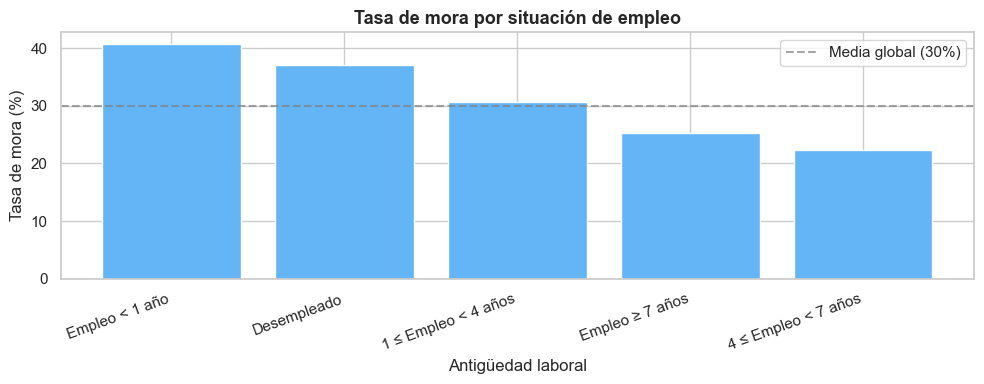

In [11]:
# Tasa de mora por situación de empleo
tasa_mora_empleo = df.groupby('empleo_actual')['riesgo'].apply(
    lambda x: (x == 2).sum() / len(x) * 100
).reset_index()
tasa_mora_empleo.columns = ['empleo_actual', 'tasa_mora_%']
tasa_mora_empleo = tasa_mora_empleo.sort_values('tasa_mora_%', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(tasa_mora_empleo['empleo_actual'], tasa_mora_empleo['tasa_mora_%'], color='#64B5F6')
ax.set_title('Tasa de mora por situación de empleo', fontsize=13, fontweight='bold')
ax.set_xlabel('Antigüedad laboral')
ax.set_ylabel('Tasa de mora (%)')
ax.axhline(y=30, color='gray', linestyle='--', alpha=0.7, label='Media global (30%)')
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

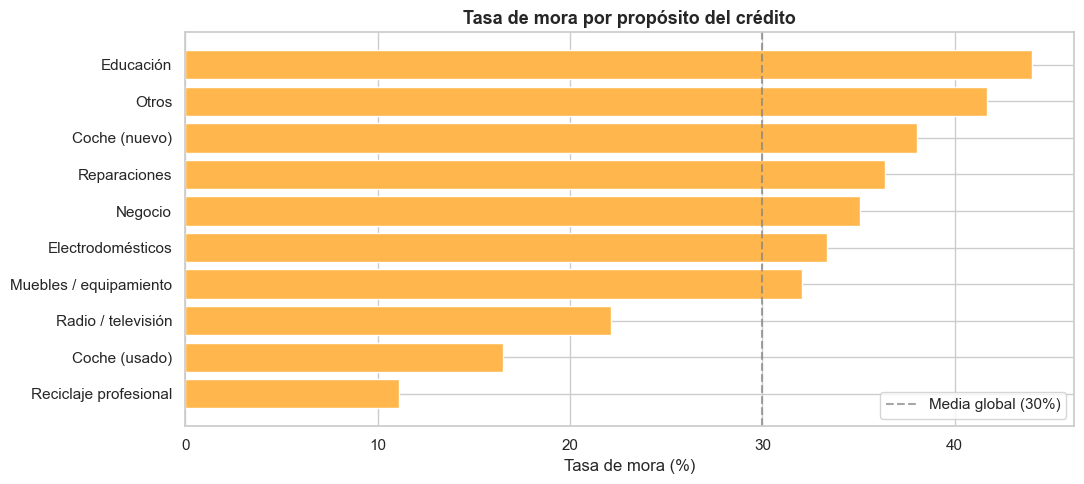

In [12]:
# Tasa de mora por propósito del crédito
tasa_mora_proposito = df.groupby('proposito')['riesgo'].apply(
    lambda x: (x == 2).sum() / len(x) * 100
).reset_index()
tasa_mora_proposito.columns = ['proposito', 'tasa_mora_%']
tasa_mora_proposito = tasa_mora_proposito.sort_values('tasa_mora_%', ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(tasa_mora_proposito['proposito'], tasa_mora_proposito['tasa_mora_%'], color='#FFB74D')
ax.set_title('Tasa de mora por propósito del crédito', fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa de mora (%)')
ax.axvline(x=30, color='gray', linestyle='--', alpha=0.7, label='Media global (30%)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Matriz de correlación (variables numéricas)

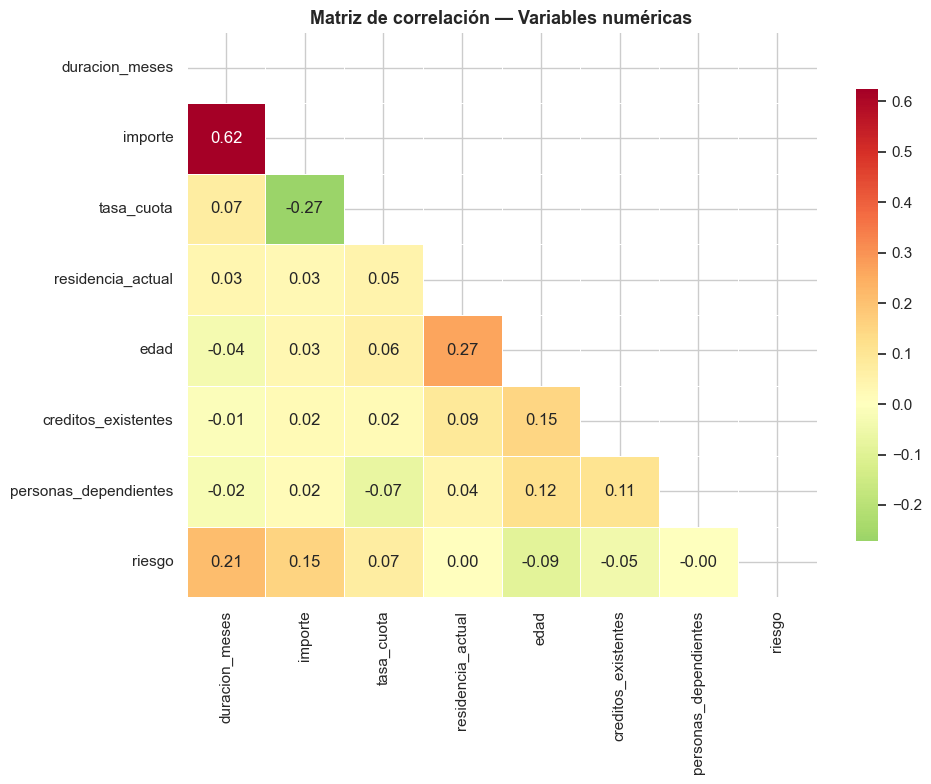

In [13]:
vars_corr = ['duracion_meses', 'importe', 'tasa_cuota', 'residencia_actual',
             'edad', 'creditos_existentes', 'personas_dependientes', 'riesgo']

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn_r', center=0, ax=ax,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación — Variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Conclusiones del EDA

---

### Hallazgos principales

**Sobre la variable objetivo:**
- El dataset presenta un desbalance 70% buenos pagadores / 30% malos pagadores, consistente con carteras bancarias reales.

**Sobre las variables numéricas:**
- Los malos pagadores tienden a solicitar **importes más elevados** y **plazos más largos** — dos señales de alerta claras para el modelo de scoring.
- La **edad** muestra una ligera correlación negativa con el riesgo: clientes más jóvenes presentan mayor tasa de mora.

**Sobre las variables categóricas:**
- El **historial crediticio** es uno de los predictores más potentes: clientes con retrasos o cuentas críticas multiplican su probabilidad de mora.
- Los créditos destinados a **educación y reciclaje profesional** presentan las tasas de mora más altas por propósito.
- La **antigüedad laboral** tiene impacto moderado: desempleados y empleados con menos de 1 año muestran mayor riesgo.

### Implicaciones para el modelo
- Será necesario **gestionar el desbalance de clases** (técnica SMOTE o ajuste de pesos).
- Las variables `importe`, `duracion_meses`, `historial_credito` y `edad` serán probablemente las más relevantes.
- En el siguiente notebook aplicaremos **codificación de variables categóricas** y **normalización** antes de modelar.

